# Todesfälle nach Bestattungsart, Geschlecht, 10-Jahres-Altersklasse und Herkunft
bev_todesfaelle_jahr_bestattungsart_herkunft_geschlecht_ag_od4204

### Kurzbeschreibung
Anzahl Todesfälle von Personen der wirtschaftlichen Wohnbevölkerung der Stadt Zürich nach Bestattungsart, Geschlecht, 10-Jahres-Altersklasse, Herkunft und Jahr.

Datum: 26.08.2024


Dataset auf PROD-Datakatalog: Link https://data.stadt-zuerich.ch/dataset/bev_todesfaelle_jahr_bestattungsart_herkunft_geschlecht_ag_od4204

Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_todesfaelle_jahr_bestattungsart_herkunft_geschlecht_ag_od4204


### Importiere die notwendigen Packages

In [49]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [1]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [2]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [3]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [4]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [5]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln


In [6]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [7]:
package_name = "bev_todesfaelle_jahr_bestattungsart_herkunft_geschlecht_ag_od4204"

In [8]:
data2betested = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BEV420OD4204"    
    , datums_attr = ['StichtagDatJahr']
    )

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_todesfaelle_jahr_bestattungsart_herkunft_geschlecht_ag_od4204/download/BEV420OD4204.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_todesfaelle_jahr_bestattungsart_herkunft_geschlecht_ag_od4204 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_todesfaelle_jahr_bestattungsart_herkunft_geschlecht_ag_od4204 

data_source: web


In [9]:
data2betested.head(2).T

,0,1
StichtagDatJahr,2014-01-01 00:00:00,2015-01-01 00:00:00
SexCd,1,1
SexKurz,M,M
SexLang,männlich,männlich
AlterV10Cd,0,0
AlterV10Lang,0- bis 9-Jährige,0- bis 9-Jährige
AlterV10Sort,1,1
HerkunftCd,1,1
HerkunftLang,Schweizer*in,Schweizer*in
HerkunftSort,1,1


Berechne weitere Attribute falls notwendig

In [10]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        StichtagDatJahr_str = lambda x: x.StichtagDatJahr.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('StichtagDatJahr', ascending=False)
    )
data2betested.dtypes

StichtagDatJahr        datetime64[ns]
SexCd                           int64
SexKurz                        object
SexLang                        object
AlterV10Cd                      int64
AlterV10Lang                   object
AlterV10Sort                    int64
HerkunftCd                      int64
HerkunftLang                   object
HerkunftSort                    int64
BestattungsCd                   int64
BestattungsKurz                object
BestattungsLang                object
AnzSterWir                      int64
StichtagDatJahr_str            object
Jahr                   datetime64[ns]
Jahr_nbr                        int32
dtype: object

Minimales und maximales Jahr im Datensatz

In [11]:
data_max_date = str(max(data2betested.Jahr).year)
data_min_date = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 2013 und ein Maximumjahr von 2024


### Einfache Datentests

In [12]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 1207 entries, 1206 to 178
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   StichtagDatJahr      1207 non-null   datetime64[ns]
 1   SexCd                1207 non-null   int64         
 2   SexKurz              1207 non-null   object        
 3   SexLang              1207 non-null   object        
 4   AlterV10Cd           1207 non-null   int64         
 5   AlterV10Lang         1207 non-null   object        
 6   AlterV10Sort         1207 non-null   int64         
 7   HerkunftCd           1207 non-null   int64         
 8   HerkunftLang         1207 non-null   object        
 9   HerkunftSort         1207 non-null   int64         
 10  BestattungsCd        1207 non-null   int64         
 11  BestattungsKurz      1207 non-null   object        
 12  BestattungsLang      1207 non-null   object        
 13  AnzSterWir           1207 non-null  

In [13]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 1,207 rows (observations) and 17 columns (variables).
There seem to be 0 exact duplicates in the data.


Beschreibe einzelne Attribute

In [14]:
data2betested.describe()

,StichtagDatJahr,SexCd,AlterV10Cd,AlterV10Sort,HerkunftCd,HerkunftSort,BestattungsCd,AnzSterWir,Jahr,Jahr_nbr
count,1207,1207,1207,1207,1207,1207,1207,1207,1207,1207
mean,2018-06-05 02:39:52.046395904,1,55,7,1,1,177,33,2018-06-05 02:39:52.046395904,2018
min,2013-01-01 00:00:00,1,0,1,1,1,176,0,2013-01-01 00:00:00,2013
25%,2015-01-01 00:00:00,1,30,4,1,1,176,2,2015-01-01 00:00:00,2015
50%,2018-01-01 00:00:00,1,60,7,1,1,177,6,2018-01-01 00:00:00,2018
75%,2021-01-01 00:00:00,2,80,9,2,2,179,21,2021-01-01 00:00:00,2021
max,2024-01-01 00:00:00,2,100,11,2,2,179,605,2024-01-01 00:00:00,2024
std,NaN,0,27,3,0,0,1,86,NaN,3


Welches sind die Quartiere ohne Werte bei BEW?

In [15]:
data2betested[np.isnan(data2betested.AnzSterWir)]

,StichtagDatJahr,SexCd,SexKurz,SexLang,AlterV10Cd,AlterV10Lang,AlterV10Sort,...,BestattungsCd,BestattungsKurz,BestattungsLang,AnzSterWir,StichtagDatJahr_str,Jahr,Jahr_nbr


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [16]:
data2betested = data2betested.set_index("StichtagDatJahr")
data2betested = data2betested.sort_index()

In [17]:
data2betested.index.year.unique()

Index([2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024], dtype='int32', name='StichtagDatJahr')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [18]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number',datetime_is_numeric=True))
except:
    print("No categorical data in dataset.")

No categorical data in dataset.


Beschreibe numerische Attribute

In [19]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,SexCd,AlterV10Cd,AlterV10Sort,HerkunftCd,HerkunftSort,BestattungsCd,AnzSterWir,Jahr_nbr
count,"1,207","1,207","1,207","1,207","1,207","1,207","1,207","1,207"
mean,1,55,7,1,1,177,33,"2,018"
std,0,27,3,0,0,1,86,3
min,1,0,1,1,1,176,0,"2,013"
25%,1,30,4,1,1,176,2,"2,015"
50%,1,60,7,1,1,177,6,"2,018"
75%,2,80,9,2,2,179,21,"2,021"
max,2,100,11,2,2,179,605,"2,024"


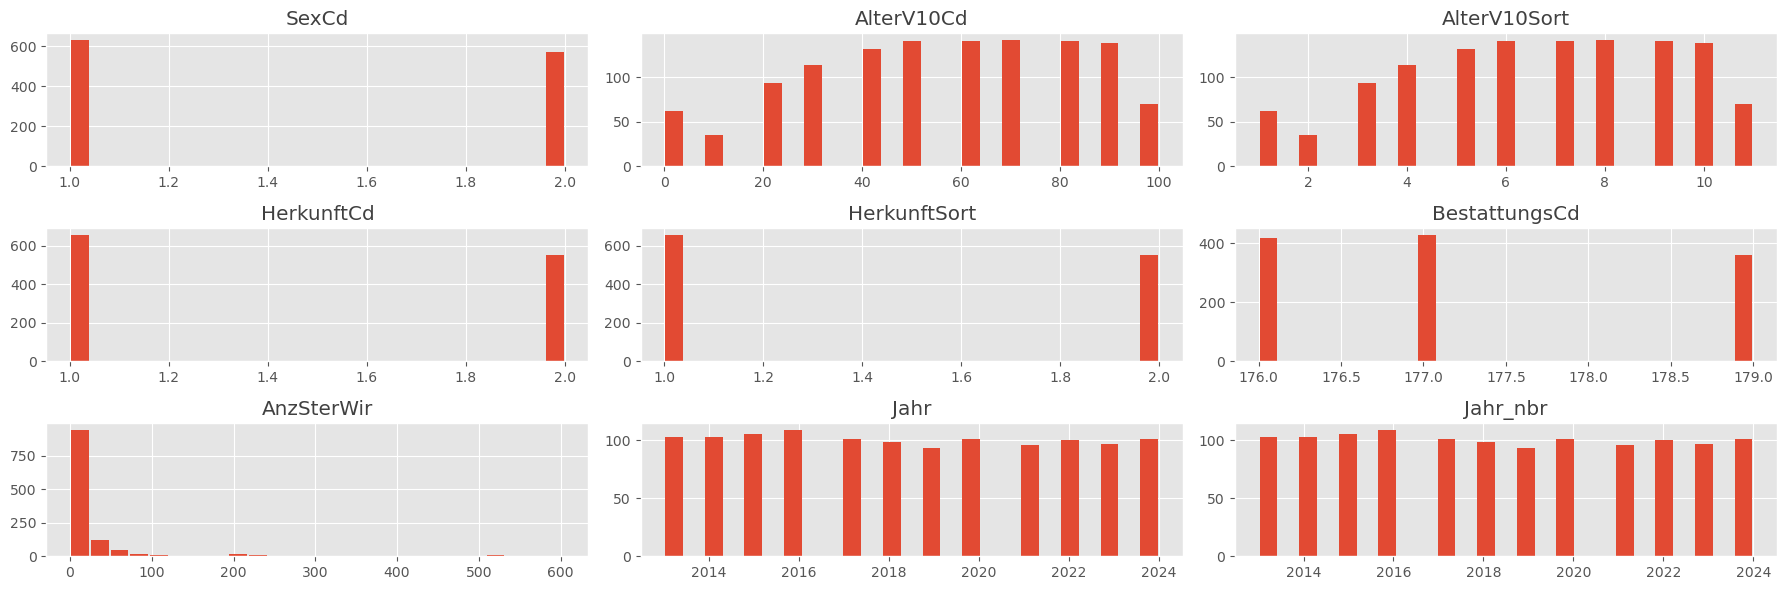

In [20]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [21]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,SexCd,SexKurz,SexLang,AlterV10Cd,AlterV10Lang,AlterV10Sort,HerkunftCd,...,BestattungsCd,BestattungsKurz,BestattungsLang,AnzSterWir,StichtagDatJahr_str,Jahr,Jahr_nbr
StichtagDatJahr,,,,,,,,,,,,,,,


### Nullwerte und Missings?

In [22]:
data2betested.isnull().sum()

SexCd                  0
SexKurz                0
SexLang                0
AlterV10Cd             0
AlterV10Lang           0
AlterV10Sort           0
HerkunftCd             0
HerkunftLang           0
HerkunftSort           0
BestattungsCd          0
BestattungsKurz        0
BestattungsLang        0
AnzSterWir             0
StichtagDatJahr_str    0
Jahr                   0
Jahr_nbr               0
dtype: int64

In [23]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [24]:
agg_jahr = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr', 'Jahr_nbr']) \
    .agg(sum_AnzSterWir=('AnzSterWir', 'sum')) \
    .sort_values('Jahr', ascending=False) 
agg_jahr.reset_index().head(3)

,Jahr,Jahr_nbr,sum_AnzSterWir
0,2024-01-01,2024,3063
1,2023-01-01,2023,3106
2,2022-01-01,2022,3350


In [25]:
agg_herk = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['HerkunftCd', 'HerkunftLang']) \
    .agg(sum_AnzSterWir=('AnzSterWir', 'sum')) \
    .sort_values('HerkunftCd', ascending=False) 
agg_herk.reset_index().head(3)

,HerkunftCd,HerkunftLang,sum_AnzSterWir
0,2,Ausländer*in,5029
1,1,Schweizer*in,34212


In [26]:
agg_age = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['AlterV10Cd', 'AlterV10Lang']) \
    .agg(sum_AnzSterWir=('AnzSterWir', 'sum')) \
    .sort_values('AlterV10Cd', ascending=True) 
agg_age.reset_index().head(11)

,AlterV10Cd,AlterV10Lang,sum_AnzSterWir
0,0,0- bis 9-Jährige,95
1,10,10- bis 19-Jährige,46
2,20,20- bis 29-Jährige,211
3,30,30- bis 39-Jährige,410
4,40,40- bis 49-Jährige,834
5,50,50- bis 59-Jährige,1924
6,60,60- bis 69-Jährige,3532
7,70,70- bis 79-Jährige,6911
8,80,80- bis 89-Jährige,13825
9,90,90- bis 99-Jährige,10832


In [27]:
agg_bestg = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['BestattungsCd','BestattungsKurz', 'BestattungsLang']) \
    .agg(sum_AnzSterWir=('AnzSterWir', 'sum')) \
    .sort_values('BestattungsCd', ascending=True) 
agg_bestg.reset_index().head(11)

,BestattungsCd,BestattungsKurz,BestattungsLang,sum_AnzSterWir
0,176,E,Erdbestattung,5390
1,177,K,Kremation,30955
2,179,UNBEK,Unbekannt,2896


In [28]:
data2betested.reset_index().columns

Index(['StichtagDatJahr', 'SexCd', 'SexKurz', 'SexLang', 'AlterV10Cd', 'AlterV10Lang',
       'AlterV10Sort', 'HerkunftCd', 'HerkunftLang', 'HerkunftSort', 'BestattungsCd',
       'BestattungsKurz', 'BestattungsLang', 'AnzSterWir', 'StichtagDatJahr_str', 'Jahr',
       'Jahr_nbr'],
      dtype='object')

### Zeitpunkte und Zeiträume abfragen

A particular powerful feature of the Pandas DataFrame is its indexing capability that also works using time-based entities, such as dates and times. We have already created the index above, so let's put it to use.

In [29]:
data2betested.loc[data_max_date].head(2)
#data2betested.loc["2021-10-31":"2021-11-30"].head(2)

,SexCd,SexKurz,SexLang,AlterV10Cd,AlterV10Lang,AlterV10Sort,HerkunftCd,...,BestattungsCd,BestattungsKurz,BestattungsLang,AnzSterWir,StichtagDatJahr_str,Jahr,Jahr_nbr
StichtagDatJahr,,,,,,,,,,,,,,,
2024-01-01,2,W,weiblich,80,80- bis 89-Jährige,9,2,...,177,K,Kremation,37,2024-01-01,2024-01-01,2024
2024-01-01,1,M,männlich,30,30- bis 39-Jährige,4,1,...,177,K,Kremation,14,2024-01-01,2024-01-01,2024


### Visualisierungen nach Zeitausschnitten

#### Entwicklung Wochenaufenthaltender nach Altersgruppe

In [30]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg1 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'AlterV10Cd', 'AlterV10Lang',]) \
    .agg(sum_AnzSterWir=('AnzSterWir', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myAgg1.reset_index().head(3)

,StichtagDatJahr,AlterV10Cd,AlterV10Lang,sum_AnzSterWir
0,2013-01-01,0,0- bis 9-Jährige,5
1,2013-01-01,10,10- bis 19-Jährige,11
2,2013-01-01,20,20- bis 29-Jährige,13


In [31]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index().sort_values('AlterV10Cd', ascending=True)
    ,x = 'StichtagDatJahr:T'
    ,y = 'sum_AnzSterWir:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "AlterV10Lang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung Todesfälle nach Altersgruppe, seit "+data_min_date
)
grafik1

alt.LayerChart(...)

#### Entwicklung nach Herkunft

In [32]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg2 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'HerkunftLang', 'HerkunftCd']) \
    .agg(sum_WBev=('AnzSterWir', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myAgg2.reset_index().head(3)

,StichtagDatJahr,HerkunftLang,HerkunftCd,sum_WBev
0,2013-01-01,Ausländer*in,2,377
1,2013-01-01,Schweizer*in,1,3088
2,2014-01-01,Ausländer*in,2,388


In [33]:
grafik2 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg2.reset_index().sort_values('HerkunftCd', ascending=True)
    ,x = 'StichtagDatJahr:T'
    ,y = 'sum_WBev:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "HerkunftLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung Todesfälle nach Herkunft, seit "+data_min_date
)
grafik2

alt.LayerChart(...)

In [34]:
data2betested.columns

Index(['SexCd', 'SexKurz', 'SexLang', 'AlterV10Cd', 'AlterV10Lang', 'AlterV10Sort', 'HerkunftCd',
       'HerkunftLang', 'HerkunftSort', 'BestattungsCd', 'BestattungsKurz', 'BestattungsLang',
       'AnzSterWir', 'StichtagDatJahr_str', 'Jahr', 'Jahr_nbr'],
      dtype='object')

In [35]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg3 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr','BestattungsCd', 'BestattungsKurz', 'BestattungsLang' ]) \
    .agg(sum_WBev=('AnzSterWir', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myAgg3.reset_index().head(3)

,StichtagDatJahr,BestattungsCd,BestattungsKurz,BestattungsLang,sum_WBev
0,2013-01-01,176,E,Erdbestattung,415
1,2013-01-01,177,K,Kremation,2303
2,2013-01-01,179,UNBEK,Unbekannt,747


In [36]:
grafik3 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg3.reset_index().sort_values('BestattungsCd', ascending=True)
    ,x = 'StichtagDatJahr:T'
    ,y = 'sum_WBev:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "BestattungsLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Todesfälle nach Bestattungsart, seit "+data_min_date
)
grafik3

alt.LayerChart(...)

#### Barcharts mit Seaborn

In [37]:
#.groupby(['StichtagDatJahr','AlterV10Cd', 'AlterV10Lang', 'HerkunftLang', 'HerkunftCd']) \
myAggBar = data2betested.loc[data_max_date]\
    .groupby(['StichtagDatJahr','AlterV10Cd', 'AlterV10Lang','BestattungsCd', 'BestattungsKurz', 'BestattungsLang']) \
    .agg(sum_WBev=('AnzSterWir', 'sum')) \
    .sort_values(['AlterV10Cd'], ascending=[True]) 

myAggBar.reset_index().head(3)

,StichtagDatJahr,AlterV10Cd,AlterV10Lang,BestattungsCd,BestattungsKurz,BestattungsLang,sum_WBev
0,2024-01-01,0,0- bis 9-Jährige,176,E,Erdbestattung,4
1,2024-01-01,0,0- bis 9-Jährige,179,UNBEK,Unbekannt,1
2,2024-01-01,10,10- bis 19-Jährige,176,E,Erdbestattung,3


In [38]:
#help(sns.catplot)   

# #Stile for the following sns graphs
sns.set_theme(style="whitegrid")

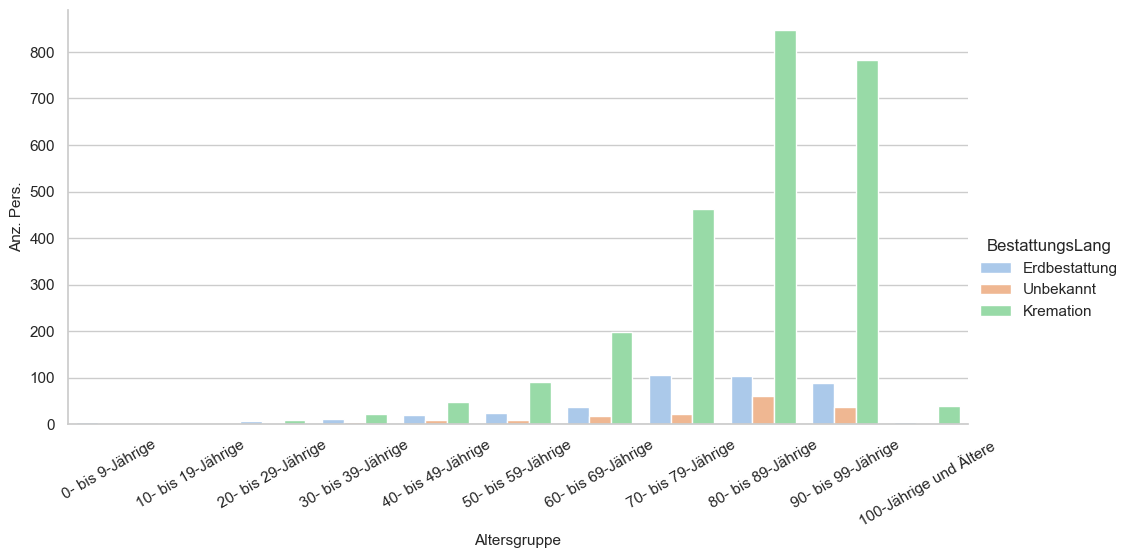

In [39]:
#sns.color_palette("flare", as_cmap=True)
myHist = sns.catplot(x="AlterV10Lang"
            , y="sum_WBev"
            , hue="BestattungsLang"
            , kind="bar" #boxen, violin, --> wenn die aggregation nicht genau den werten in der grafik entspricht
            , palette="pastel" #, color="green"
            , height=5
            , aspect=2
            , order=None, legend_out=True
            ,data=myAggBar.reset_index()
           )
myHist.set_xticklabels(rotation=30) 
myHist.set_xlabels('Altersgruppe', fontsize=11) # not set_label
myHist.set_ylabels('Anz. Pers.', fontsize=11)


#### Faced Grids

In [40]:
data2betested.columns

Index(['SexCd', 'SexKurz', 'SexLang', 'AlterV10Cd', 'AlterV10Lang', 'AlterV10Sort', 'HerkunftCd',
       'HerkunftLang', 'HerkunftSort', 'BestattungsCd', 'BestattungsKurz', 'BestattungsLang',
       'AnzSterWir', 'StichtagDatJahr_str', 'Jahr', 'Jahr_nbr'],
      dtype='object')

In [41]:
#.query('HerkunftLang !="Ausland"')
myFG = data2betested\
    .groupby(['StichtagDatJahr','AlterV10Cd', 'AlterV10Lang','BestattungsCd', 'BestattungsKurz', 'BestattungsLang','HerkunftCd','HerkunftLang', 'HerkunftSort',]) \
    .agg(sum_WBev=('AnzSterWir', 'sum')) \
    .sort_values('AlterV10Cd', ascending=True) 
myFG

sum_WBev
StichtagDatJahr AlterV10Cd AlterV10Lang           BestattungsCd BestattungsKurz BestattungsLang HerkunftCd HerkunftLang HerkunftSort          
2013-01-01      0          0- bis 9-Jährige       176           E               Erdbestattung   1          Schweizer*in 1                    2
2020-01-01      0          0- bis 9-Jährige       177           K               Kremation       2          Ausländer*in 2                    1
                                                                                                1          Schweizer*in 1                    4
                                                  176           E               Erdbestattung   1          Schweizer*in 1                    3
2019-01-01      0          0- bis 9-Jährige       179           UNBEK           Unbekannt       1          Schweizer*in 1                    1
...                                                                                                                                        ...
2016-01-01      100        100-Jährige und Ältere 177           K               Kremation       1          Schweizer*in 1                   34
                                                  176           E               Erdbestattung   2          Ausländer*in 2                    2
                                                                                                1          Schweizer*in 1                    9
2019-01-01      100        100-Jährige und Ältere 177           K               Kremation       1          Schweizer*in 1                   48
2024-01-01      100        100-Jährige und Ältere 179           UNBEK           Unbekannt       1          Schweizer*in 1                    2

[677 rows x 1 columns]

In [42]:
myFG.reset_index().columns

Index(['StichtagDatJahr', 'AlterV10Cd', 'AlterV10Lang', 'BestattungsCd', 'BestattungsKurz',
       'BestattungsLang', 'HerkunftCd', 'HerkunftLang', 'HerkunftSort', 'sum_WBev'],
      dtype='object')

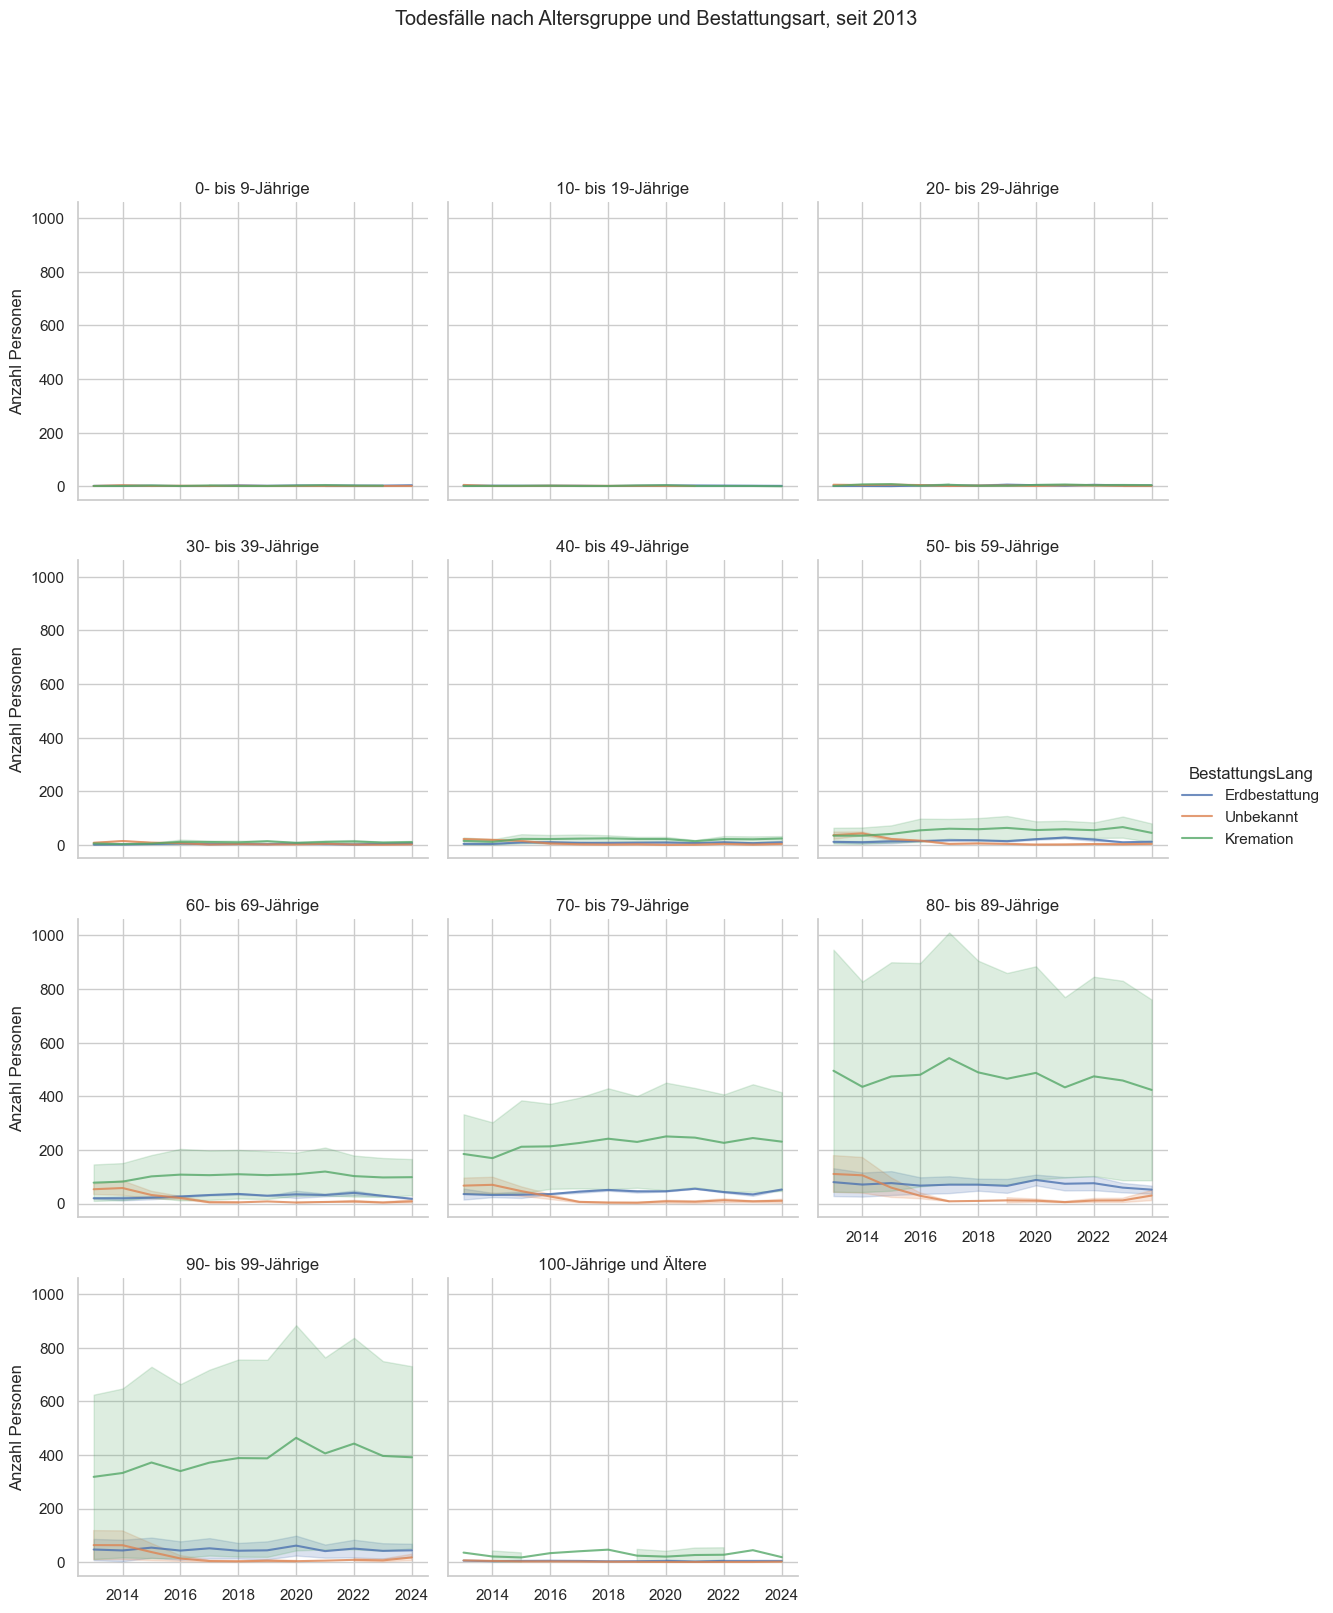

In [43]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = myFG.reset_index().sort_values('AlterV10Cd', ascending=True)
    ,col = "AlterV10Lang"
    ,hue = "BestattungsLang"
    ,col_wrap = 3
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "sum_WBev"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Todesfälle nach Altersgruppe und Bestattungsart, seit "+str(int(data2betested.index.year.min()))
)
faced_grid1

#### Treemaps

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [44]:
  qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
  qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
  qual12da = ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
  div9val = ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB",]
  div9ntr = ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A",]

In [45]:
data2betested.columns

Index(['SexCd', 'SexKurz', 'SexLang', 'AlterV10Cd', 'AlterV10Lang', 'AlterV10Sort', 'HerkunftCd',
       'HerkunftLang', 'HerkunftSort', 'BestattungsCd', 'BestattungsKurz', 'BestattungsLang',
       'AnzSterWir', 'StichtagDatJahr_str', 'Jahr', 'Jahr_nbr'],
      dtype='object')

In [50]:
# Extrahiere die Top-Fahrzeugmarken
attr2becolored = data2betested['AlterV10Lang'].unique().tolist()
# Verfügbare Farben
verfügbare_farben_zuericolors = qual12da+qual12br+qual12+div9ntr

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(attr2becolored):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', '30- bis 39-Jährige': '#0017BF', '90- bis 99-Jährige': '#0072D7', '100-Jährige und Ältere': '#00A5D2', '0- bis 9-Jährige': '#5E359A', '50- bis 59-Jährige': '#BA0062', '10- bis 19-Jährige': '#DA5563', '20- bis 29-Jährige': '#00615D', '40- bis 49-Jährige': '#00770F', '60- bis 69-Jährige': '#7BA600', '80- bis 89-Jährige': '#7B4100', '70- bis 79-Jährige': '#DC5500'}


##### Todesfälle nach Altersgruppe, Herkunft, Geschlecht und Bestattungsart

In [51]:
data2betested.columns

Index(['SexCd', 'SexKurz', 'SexLang', 'AlterV10Cd', 'AlterV10Lang', 'AlterV10Sort', 'HerkunftCd',
       'HerkunftLang', 'HerkunftSort', 'BestattungsCd', 'BestattungsKurz', 'BestattungsLang',
       'AnzSterWir', 'StichtagDatJahr_str', 'Jahr', 'Jahr_nbr'],
      dtype='object')

In [53]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=data2betested.reset_index()
    ,levels=['AlterV10Lang','SexLang', 'HerkunftLang', 'BestattungsLang']
    ,values="AnzSterWir"
    ,color="AnzSterWir"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Todesfälle nach Altersgruppe, Geschlecht, Herkunft und Bestattungsart, seit "+data_min_date
)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x0000011E95DD0ED0>, 'AlterV10Lang', 'SexLang', 'HerkunftLang', 'BestattungsLang']
Typ von path: <class 'list'>


##### Wochenaufenthaltende nach Altersgruppe und Zuzugsgebiet

In [ ]:
#agg_age
#agg_age.reset_index().dtypes

In [54]:
treeMap2= mypy_dv.plot_px_treemap(
    data=data2betested.loc[data_max_date].reset_index()
    ,levels=['HerkunftLang','SexLang', 'AlterV10Lang', 'BestattungsLang']
    ,values="AnzSterWir"
    ,color="AlterV10Lang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Todesfälle nach Altersgruppe, Geschlecht, Herkunft und Bestattungsart, "+data_max_date
)

treeMap2

path: [<plotly.express._special_inputs.Constant object at 0x0000011E9A549E10>, 'HerkunftLang', 'SexLang', 'AlterV10Lang', 'BestattungsLang']
Typ von path: <class 'list'>


In [55]:
treeMap3= mypy_dv.plot_px_treemap(
    data=data2betested.loc[data_max_date].reset_index()
    ,levels=['BestattungsLang', 'HerkunftLang', 'AlterV10Lang','SexLang' ]
    ,values="AnzSterWir"
    ,color="AlterV10Lang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Todesfälle nach Altersgruppe, Geschlecht, Herkunft und Bestattungsart, "+data_max_date
)

treeMap3

path: [<plotly.express._special_inputs.Constant object at 0x0000011E9A24E910>, 'BestattungsLang', 'HerkunftLang', 'AlterV10Lang', 'SexLang']
Typ von path: <class 'list'>


## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=1434&Source=https%3A%2F%2Fkollaboration%2Eintranet%2Estzh%2Ech%2Forga%2Fssz%2Dprodukte%2FLists%2FSASA%5FOutputs%2FPersonalViews%2Easpx%3FPageView%3DPersonal%26ShowWebPart%3D%7B6087A3E7%2D8AC8%2D40BA%2D8278%2DDECFACE124FF%7D%23InplviewHash6087a3e7%2D8ac8%2D40ba%2D8278%2Ddecface124ff%3D&ContentTypeId=0x0100988EAF029F1EFE4CA675F53C32A5D53D01006DBC563E6FBE9E4EB6FDC780799752E1)**

---------------------------------------------------------------------------